In [12]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from utils.data_loader import load_gbs_allensbach, load_gbs_gesis
from sklearn.discriminant_analysis import StandardScaler

In [13]:
try:
    if DATA_IS_LOADED:
        pass
except:
    df, columns, target = load_gbs_gesis()
    scaler = StandardScaler()
    scaler = scaler.fit(df[columns])
    df[columns] = scaler.transform(df[columns])
    scaled_df = df.copy()
    N = scaled_df[scaled_df["label"] == 1]
    R = scaled_df[scaled_df["label"] == 0]
    replacer = {}
    for i, feature_name in enumerate(columns):
        replacer[i] = feature_name
DATA_IS_LOADED = True

In [14]:
method_name = "fw-mrs-temperature"
data_set_name = "gbs_gesis"

In [15]:
load_path = f"../results/statistical_analysis/{data_set_name}/{method_name}/abs_feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)

representative_uniform_load_path = f"../results/statistical_analysis/{data_set_name}/uniform/abs_feature_importance.json"
with open(representative_uniform_load_path) as file:
    uniform_feature_importance = json.load(file)

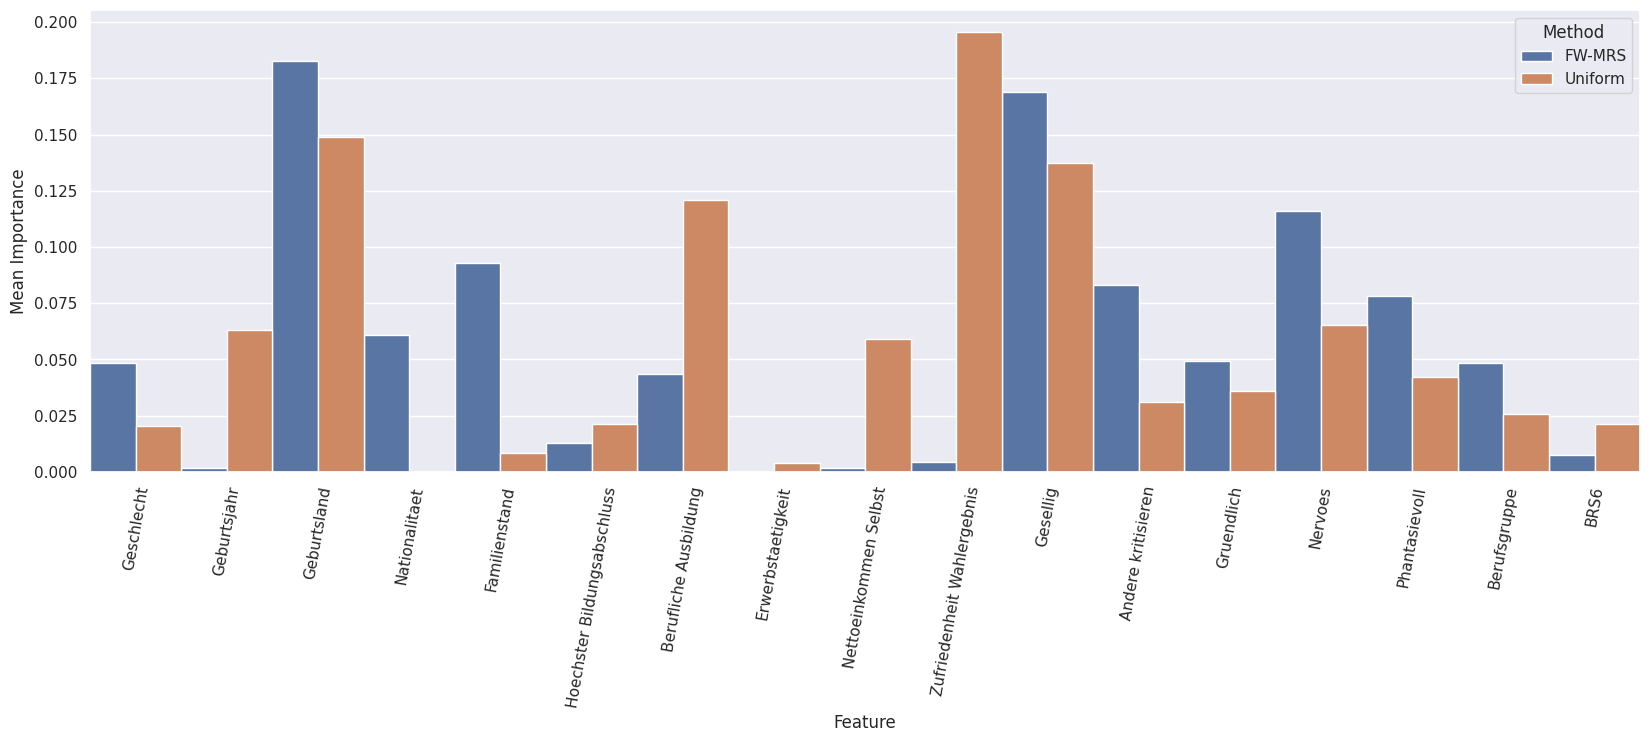

In [16]:
sns.set_theme(rc={'figure.figsize':(20,6)})
mean_iteration_feature_importance = np.mean(feature_importance, axis=0)
mean_iteration_feature_importance /= np.sum(mean_iteration_feature_importance)

mean_uniform_feature_importance = np.mean(uniform_feature_importance, axis=0)
mean_uniform_feature_importance /=  np.sum(mean_uniform_feature_importance)

feature_importances = pd.DataFrame(
    [
        {"Method": "FW-MRS", "Mean Importance": np.array(mean_iteration_feature_importance)},
        {"Method": "Uniform", "Mean Importance": np.array(mean_uniform_feature_importance)},
     ]
        )
feature_importances = feature_importances.explode(["Mean Importance"])
feature_importances['Feature'] = feature_importances.groupby('Method').cumcount()
feature_importances["Feature"] = feature_importances["Feature"].replace(replacer)
ax = sns.barplot(feature_importances, x="Feature" , y="Mean Importance", hue="Method", width=1)
_ = plt.xticks(rotation = 80)

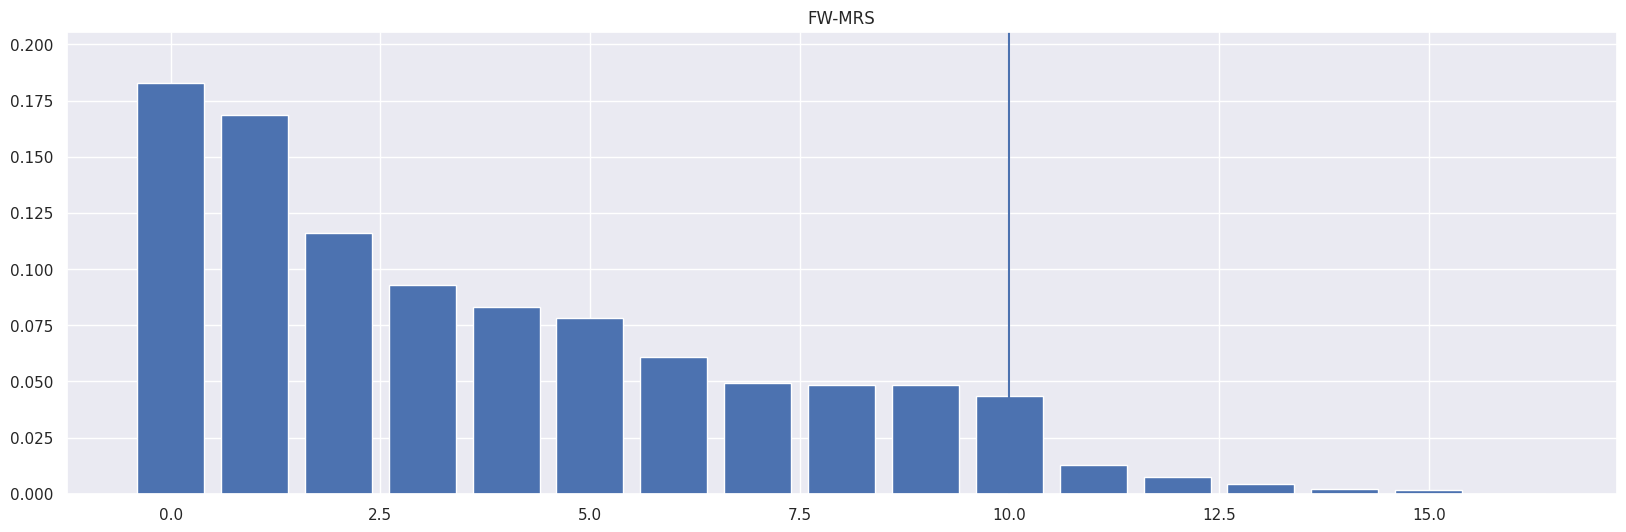

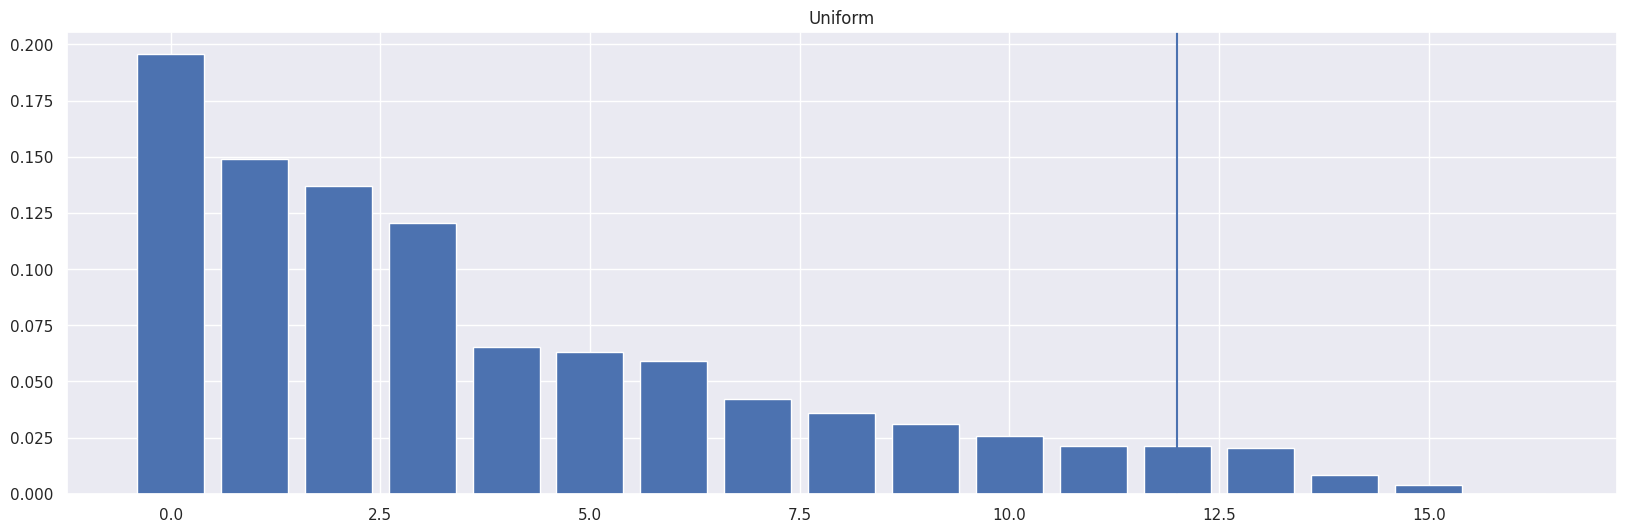

In [17]:
xticks, xlabels = [], []
feature_importances['Mean Importance'] = feature_importances['Mean Importance'].astype("float32")
max_importance = np.max(feature_importances['Mean Importance'])
cut = 0.95
for (idx, group) in feature_importances.groupby('Method'):
    plot_data = group.nlargest(len(columns), 'Mean Importance')
    x = [x for x in range(len(columns))]
    sum_value = 0
    for i, value in enumerate(plot_data["Mean Importance"]):
        sum_value+= value
        if sum_value >= cut:
            break
    plt.axvline(i)
    plt.bar(x=x, height=plot_data['Mean Importance'])
    plt.title(idx)
    xticks += x
    
    xlabels += plot_data['Feature'].tolist()
    plt.ylim(0, max_importance + 0.01)
    plt.show()